# Data gathering
This notebook explains how to use the shared package and scripts in the data_gathering folder to create new datasets.

### Import packages and define Output location

In [1]:
import sys
import os

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.insert(0, parent_dir)

from shared import MarkerDetectionConfig
from data_gathering.gather_robot_data import *
from data_gathering.depth_filtering import *

output_folder = "../example_datasets"

### Gather Data
This will use the deoxy's installation to gather data using the panda robot.

The positions file contains the joint positions that should be used. New joint position files can be generated using the `data_gathering/read_joint.py` script.

In [2]:
positions_file = "../data_gathering/pos11.csv"

from data_gathering.robot_interface import gather_robot_data

proto_data = gather_robot_data(
    number_of_positions = None,
    stabilisation_timeout= 1.0,
    position_file = positions_file,
    depth_filter_config=DepthOptimisationConfig()
)

pybullet build time: Jan 29 2025 23:16:28


JOINT_POSITION
JOINT_POSITION
JOINT_POSITION
JOINT_POSITION
JOINT_POSITION
JOINT_POSITION
JOINT_POSITION
JOINT_POSITION
JOINT_POSITION
JOINT_POSITION
JOINT_POSITION


### Define the Marker
Now a marker detection config should be created, that tells the dataset creator the type of marker in a scene.

MarkerDetectionConfig Hyperparameters:
- *marker_type* 'Aruco'/'Charuco' or None are currently supported

- *marker_side_length* The side length of the marker in meters

- *aruco_marker_dictionary* The dictionary of the Aruco marker, as a string of the form "MxM_N", e.g. "5X5_250"

- *board_size* The number of squares along each axis for charuco boards

- *min_fraction_of_markers* The min fraction of markers on a charuco board to return a prediction

optimize_robot_data Hyperparameters:
- *base_t_gripper_outlier_quantiles*, the rotational and translational error quantiles, higher numbers -> higher removal percentage. High numbers cause only marker pose estimates close to their median to be left.
- *gripper_t_cam*, accepts a 4x4 homogeneous matrix for the gripper -> cam transformation, not needed if a marker_detector is provided

Check output data will output metrics about the marker estimates in the resulting dataset.

Using aruco markers for gripper_T_cam determination


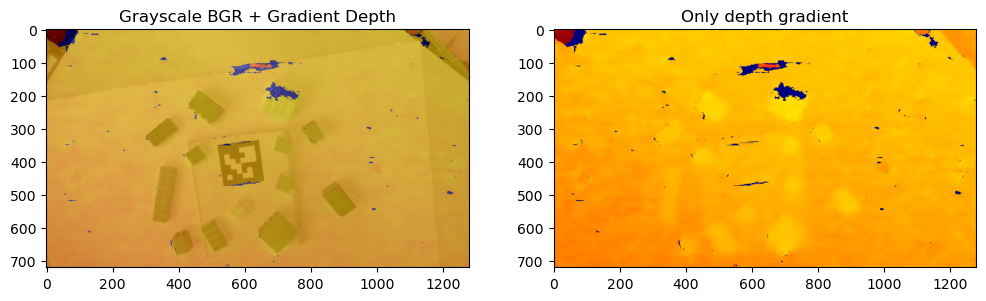

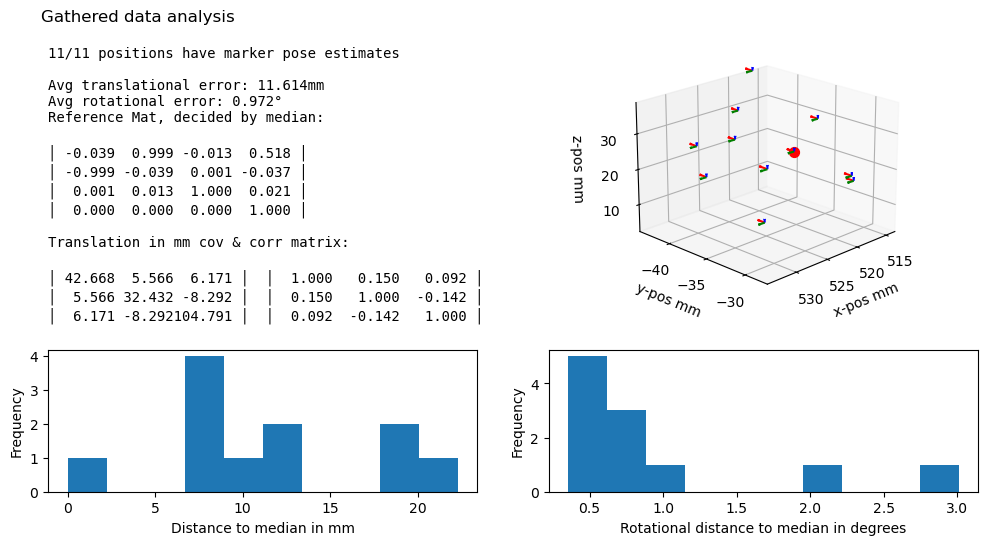

In [3]:
SCENE_NAME = "mixed1"

small_aruco =  MarkerDetectionConfig(
    marker_type= "Aruco",
    marker_side_length = 0.1,
    aruco_marker_dictionary= "6X6_250"
)

gathered_robot_data = optimize_robot_data(
    proto_data=proto_data,
    gripper_t_cam=None,
    marker_detector = MarkerDetector.from_config(small_aruco),
    base_t_gripper_outlier_quantiles=(0.0, 0.0),
)
gathered_robot_data.see_color_depth_alignment()
check_output_data(gathered_data = gathered_robot_data, use_mean = False, save_result = False)
gathered_robot_data.save(folder=output_folder, new_name=SCENE_NAME)